### Explore and Plot PIPERS CTD Data 

#### Data Info: 

Antarctic coastline data: 


Gerrish, L., Ireland, L., Fretwell, P., Cooper, P., & Skachkova, A. (2025). High resolution vector polygons of the Antarctic coastline - VERSION 7.11 (Version 7.11) [Data set]. NERC EDS UK Polar Data Centre. https://doi.org/10.5285/7d6793c2-2513-4752-8f37-11db5b791fb5


Bathymetry data (Sub-ice topo/bath grid is used): 


GEBCO Bathymetric Compilation Group 2026(2026). The GEBCO_2026 Grid - a continuous terrain model for oceans and land at 15 arc-second intervals. NERC EDS British Oceanographic Data Centre NOC. doi:10.5285/4f68d5c7-45eb-f999-e063-7086abc036fa


PIPERS CTD Data: 

Stammerjohn, S. (2019) "NBP1704 CTD sensor data" U.S. Antarctic Program (USAP) Data Center. doi: https://doi.org/10.15784/601422.




In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr
import geopandas as gpd
import cartopy.crs as ccrs
from shapely.geometry import box
import matplotlib.dates as mdates

In [2]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import xarray as xr


def julian_to_datetime(julian, year):
    base = pd.Timestamp(f"{year}-01-01")
    return base + pd.to_timedelta(julian - 1, unit="D")


def read_downcast_txt(file, year=None):
    file = Path(file)

    # Try to parse year from filename like nbp1704_01d.txt or nbp_1704_01d.txt
    if year is None:
        match = re.search(r"nbp_?(\d{2})", file.stem)
        if match is None:
            raise ValueError(
                "Could not infer year from filename. "
                "Pass year explicitly, e.g. read_downcast_txt(file, year=2017)"
            )
        year = int("20" + match.group(1))

    columns = [
        "press", "depth", "time_julian", "lat", "lon",
        "temp", "cond", "O2", "theta", "sal", "sigma_theta",
        "fluor", "PAR", "beam_trans", "beam_atten", "FLBB1", "FLBB2"
    ]

    df = pd.read_csv(
        file,
        sep=r"\s+",
        skiprows=1,
        names=columns,
        engine="python"
    )

    # Replace common bad values
    df = df.replace([-999, -9999, -99, 1e35], np.nan)

    # Convert Julian day to datetime
    df["datetime"] = julian_to_datetime(df["time_julian"], year)

    # Save scalar metadata BEFORE grouping
    lat_mean = df["lat"].mean()
    lon_mean = df["lon"].mean()
    time_mean = df["datetime"].mean()

    # Sort by pressure
    df = df.sort_values("press")

    # Drop scalar metadata columns before pressure grouping
    df = df.drop(columns=["lat", "lon", "time_julian", "datetime"])

    # Average duplicate pressure bins
    df = df.groupby("press", as_index=False).mean(numeric_only=True)

    # Convert to xarray with pressure as dimension
    ds = df.set_index("press").to_xarray()

    # Add scalar coordinates
    ds = ds.assign_coords(
        lat=float(lat_mean),
        lon=float(lon_mean),
        time=pd.to_datetime(time_mean),
    )

    ds.attrs["source_file"] = file.name
    ds.attrs["year"] = year

    return ds

In [3]:
folder = "/Users/mblan/Documents/TNB_Research/data/PIPERS_CTD_2017/final_ascii_v2"

In [4]:
folder + "/nbp1704_01d.txt"

'/Users/mblan/Documents/TNB_Research/data/PIPERS_CTD_2017/final_ascii_v2/nbp1704_01d.txt'

In [5]:
ds = read_downcast_txt(folder + "/nbp1704_01d.txt")

In [6]:
ds

<xarray.Dataset> Size: 227kB
Dimensions:      (press: 2024)
Coordinates:
  * press        (press) int64 16kB 8 9 10 11 12 13 ... 2027 2028 2029 2030 2031
    lat          float64 8B -60.0
    lon          float64 8B 170.0
    time         datetime64[ns] 8B 2017-04-16T00:20:09.600000
Data variables: (12/13)
    depth        (press) float64 16kB 7.92 8.91 9.9 ... 2.001e+03 2.002e+03
    temp         (press) float64 16kB 5.301 5.301 5.301 ... 1.796 1.794 1.791
    cond         (press) float64 16kB 3.272 3.272 3.272 ... 3.127 3.127 3.127
    O2           (press) float64 16kB 6.99 6.995 6.995 ... 4.418 4.422 4.427
    theta        (press) float64 16kB 5.301 5.301 5.3 5.3 ... 1.659 1.657 1.655
    sal          (press) float64 16kB 33.84 33.84 33.84 ... 34.74 34.74 34.74
    ...           ...
    fluor        (press) float64 16kB 0.226 0.227 0.23 ... 0.042 0.038 0.042
    PAR          (press) float64 16kB 133.0 119.0 115.0 ... 0.000298 0.000293
    beam_trans   (press) float64 16kB 99.4 99.41 99.4 99.4 ... 100.6 100.6 100.6
    beam_atten   (press) float64 16kB 0.0242 0.0238 0.024 ... -0.0231 -0.0233
    FLBB1        (press) float64 16kB 0.1107 0.1113 0.1152 ... 0.0682 0.0673
    FLBB2        (press) float64 16kB 0.1731 0.1753 0.1805 ... 0.1324 0.1334
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

In [7]:
from pathlib import Path
import re

folder = Path("/Users/mblan/Documents/TNB_Research/data/PIPERS_CTD_2017/final_ascii_v2")

casts = {}

for file in sorted(folder.glob("*.txt")):

    stem = file.stem  # filename without .txt

    # Only keep files ending in d
    if not stem.endswith("d"):
        continue

    # Extract station number before the final "d"
    # Works for filenames like:
    # nbp1704_01d
    # nbp_1704_01d
    match = re.search(r"_(\d{2})d$", stem)

    if match is None:
        print(f"Skipping unclear filename: {file.name}")
        continue

    station = int(match.group(1))  # "01" -> 1

    ds = read_downcast_txt(file)
    ds = ds.assign_coords(station=station)

    casts[station] = ds

In [8]:
casts.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58])

In [9]:
cast = casts[50]

Text(0.5, 0, 'Sal')

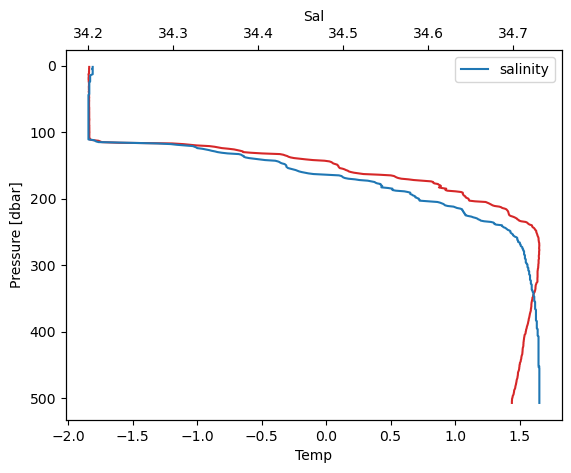

In [10]:
fig, ax = plt.subplots()
ax.plot(cast.temp,cast.press,color='tab:red',label='Temp')
ax.invert_yaxis()
ax1 = ax.twiny()
ax1.plot(cast.sal,cast.press,color='tab:blue',label='salinity')
plt.legend()
ax.set_ylabel('Pressure [dbar]')
ax.set_xlabel('Temp')
ax1.set_xlabel('Sal')

In [11]:
casts[58]

<xarray.Dataset> Size: 57kB
Dimensions:      (press: 506)
Coordinates:
  * press        (press) int64 4kB 3 4 5 6 7 8 9 ... 502 503 504 505 506 507 508
    lat          float64 8B -66.15
    lon          float64 8B -175.3
    time         datetime64[ns] 8B 2017-06-05T09:53:16.799999744
    station      int64 8B 58
Data variables: (12/13)
    depth        (press) float64 4kB 2.97 3.96 4.95 5.94 ... 500.4 501.4 502.4
    temp         (press) float64 4kB -1.78 -1.782 -1.785 ... 1.445 1.444 1.444
    cond         (press) float64 4kB 2.681 2.68 2.68 2.68 ... 3.031 3.031 3.031
    O2           (press) float64 4kB 7.896 7.901 7.898 ... 4.559 4.569 4.571
    theta        (press) float64 4kB -1.78 -1.782 -1.785 ... 1.419 1.418 1.418
    sal          (press) float64 4kB 34.0 34.0 34.0 34.0 ... 34.73 34.73 34.73
    ...           ...
    fluor        (press) float64 4kB 0.255 0.21 0.218 ... 0.048 0.042 0.047
    PAR          (press) float64 4kB 0.0224 0.0363 0.0284 ... 0.00028 0.000292
    beam_trans   (press) float64 4kB 99.87 99.82 99.85 ... 100.5 100.5 100.5
    beam_atten   (press) float64 4kB 0.0053 0.0073 0.0059 ... -0.021 -0.0206
    FLBB1        (press) float64 4kB nan nan nan nan nan ... nan nan nan nan nan
    FLBB2        (press) float64 4kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    source_file:  nbp1704_58d.txt
    year:         2017

In [12]:
bath = xr.open_dataset("//thepenguin/penguin2/Data/TNB/bathymetry/bath_ross_amundsen.nc")

In [13]:
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
from shapely.validation import make_valid

# read fresh
gdf = gpd.read_file(
    "/Users/mblan/Documents/research/data/add_coastline_high_res_polygon_v7_11/add_coastline_high_res_polygon_v7_11.shp"
)

if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
else:
    gdf = gdf.to_crs("EPSG:4326")

# better than buffer(0)
gdf["geometry"] = gdf.geometry.apply(make_valid)

ice = gdf[gdf["surface"].isin(["ice shelf", "ice tongue"])]
land = gdf[gdf["surface"].isin(["land"])]

In [14]:
def subset_dateline_gdf(gdf, lat_min=-78, lat_max=-60):
    # Ross sector: 160E to 180, plus 180 to 160W
    east = gdf.cx[160:180, lat_min:lat_max]
    west = gdf.cx[-180:-160, lat_min:lat_max]

    out = pd.concat([east, west], ignore_index=True)
    return gpd.GeoDataFrame(out, crs=gdf.crs)

In [52]:
def TNB_study_site(
    bath,
    ice,
    land,
    lon_min=160,
    lon_max=200,
    lat_min=-78,
    lat_max=-60,
    figsize=(8, 6),
    central_longitude=165,
    contour_levels=None,
    n_contours=5,
    contour_min=200,
    contour_max=1200,
    contour_color="black",
    contour_lw=0.7,
    label_contours=True,
    gridline_lons=None,
    gridline_lats=None,
):
    """
    Create a reusable Terra Nova Bay / Ross Sea study-site map.

    Parameters
    ----------
    bath : xarray.Dataset
        GEBCO bathymetry dataset with variables lon, lat, elevation.
    ice, land : geopandas.GeoDataFrame
        SCAR ADD clipped/unclipped ice and land polygons.
    lon_min, lon_max, lat_min, lat_max : float
        Map extent in lon/lat.
    contour_levels : list or array, optional
        Specific bathymetry contour levels in positive meters.
        Example: [400, 600, 800, 1000]
    n_contours : int
        Number of contours if contour_levels is not provided.
    contour_min, contour_max : float
        Min/max depth contours if contour_levels is not provided.
    """

    # -----------------------------
    # Projection / figure
    # -----------------------------
    proj = ccrs.SouthPolarStereo(central_longitude=central_longitude)

    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": proj},
        constrained_layout=True
    )

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    # -----------------------------
    # Gridlines
    # -----------------------------
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    if gridline_lons is not None:
        gl.xlocator = mticker.FixedLocator(gridline_lons)

    if gridline_lats is not None:
        gl.ylocator = mticker.FixedLocator(gridline_lats)

    # -----------------------------
    # Bathymetry subset
    # -----------------------------
    # bath_sub = bath.sortby("lat").sortby("lon").sel(
    #     lat=slice(lat_min, lat_max),
    #     lon=slice(lon_min, lon_max)
    # )

    # depth = -bath_sub["elevation"]

    # if contour_levels is None:
    #     contour_levels = np.linspace(contour_min, contour_max, n_contours)

    # contours = ax.contour(
    #     depth["lon"],
    #     depth["lat"],
    #     depth,
    #     levels=contour_levels,
    #     colors=contour_color,
    #     linewidths=contour_lw,
    #     transform=ccrs.PlateCarree(),
    #     zorder=2
    # )
    pad = 15

    bath_sub = bath.sortby("lat").sortby("lon").sel(
        lat=slice(lat_min - pad, lat_max + pad),
        lon=slice(lon_min - pad, lon_max + pad)
    )

    depth = -bath_sub["elevation"]

    # keep only ocean
    # depth = depth.where(depth > 0)

    if contour_levels is None:
        contour_levels = np.linspace(
            contour_min,
            contour_max,
            n_contours
        )

    contours = ax.contour(
        depth["lon"],
        depth["lat"],
        depth,
        levels=contour_levels,
        colors=contour_color,
        linewidths=contour_lw,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    if label_contours:
        ax.clabel(
            contours,
            fmt="%d m",
            fontsize=8,
            inline=True,
            inline_spacing=1
        )

    # -----------------------------
    # Clip coastline polygons
    # -----------------------------

    # regional subset only, no clipping
    ice_reg = subset_dateline_gdf(ice, lat_min=lat_min, lat_max=lat_max)
    land_reg = subset_dateline_gdf(land, lat_min=lat_min, lat_max=lat_max)

    # project polygons into the map projection before plotting
    ice_proj = ice_reg.to_crs(proj.proj4_init)
    land_proj = land_reg.to_crs(proj.proj4_init)

    ax.add_geometries(
        ice_proj.geometry,
        crs=proj,
        facecolor="lightgrey",
        edgecolor="k",
        linewidth=0.3,
        zorder=3,
    )

    ax.add_geometries(
        land_proj.geometry,
        crs=proj,
        facecolor="grey",
        edgecolor="k",
        linewidth=0.3,
        zorder=4,
    )

    return fig, ax

In [16]:
lons = [float(ds.lon) for ds in casts.values()]
lats = [float(ds.lat) for ds in casts.values()]

In [17]:
np.min(lons), np.max(lons)

(np.float64(-179.48), np.float64(179.99700000000004))

In [18]:
np.min(lats), np.max(lats)

(np.float64(-77.72000000000003), np.float64(-60.0))

In [19]:
# bath = bath.assign_coords(lon=(bath.lon % 360))
# bath = bath.sortby("lon")

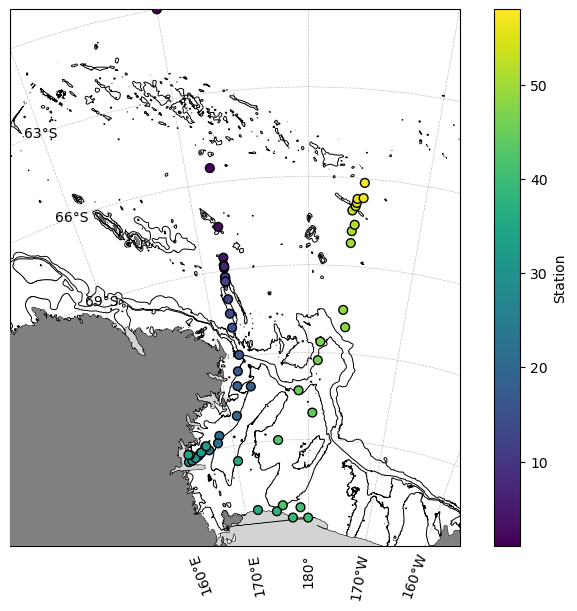

In [ ]:
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=160,
    lon_max=190,
    lat_min=-78,
    lat_max=-50,
    central_longitude=180,
    contour_levels=[500,1000,2000],
    gridline_lons=[160, 170, 180, -170, -160],
    gridline_lats=[-75, -72, -69, -66, -63, -60],
    label_contours=False,
)

stations = list(casts.keys())
lons = [float(ds.lon) for ds in casts.values()]
lats = [float(ds.lat) for ds in casts.values()]

sc = ax.scatter(
    lons,
    lats,
    c=stations,
    cmap='viridis',
    s=40,
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

plt.colorbar(sc, ax=ax, label='Station')



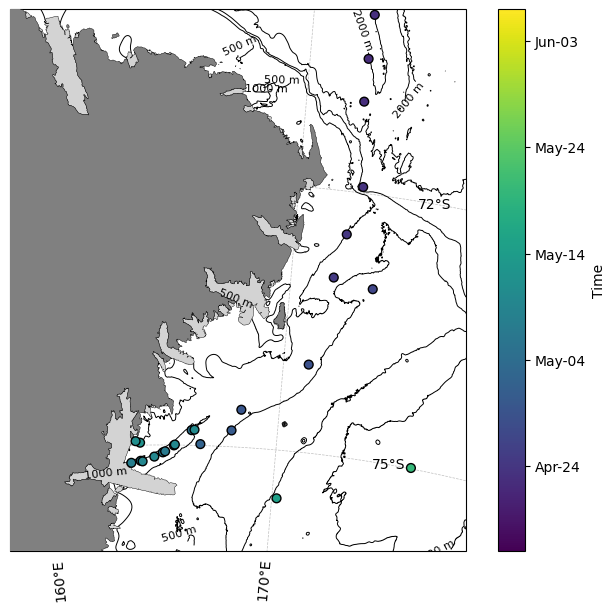

In [59]:
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=160,
    lon_max=175,
    lat_min=-76,
    lat_max=-70,
    central_longitude=165,
    contour_levels=[500,1000,2000],
    gridline_lons=[160, 170, 180, -170, -160],
    gridline_lats=[-75, -72, -69, -66, -63, -60],
    label_contours=True,
)

# stations = list(casts.keys())
# lons = [float(ds.lon) for ds in casts.values()]
# lats = [float(ds.lat) for ds in casts.values()]

# sc = ax.scatter(
#     lons,
#     lats,
#     c=stations,
#     cmap='viridis',
#     s=40,
#     edgecolor='k',
#     transform=ccrs.PlateCarree(),
#     zorder=10
# )

# plt.colorbar(sc, ax=ax, label='Station')

time_num = mdates.date2num(ctd.time.values)

sc = ax.scatter(
    ctd.lon,
    ctd.lat,
    c=time_num,
    cmap='viridis',
    s=40,
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Time")

# Convert colorbar ticks back to readable dates
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

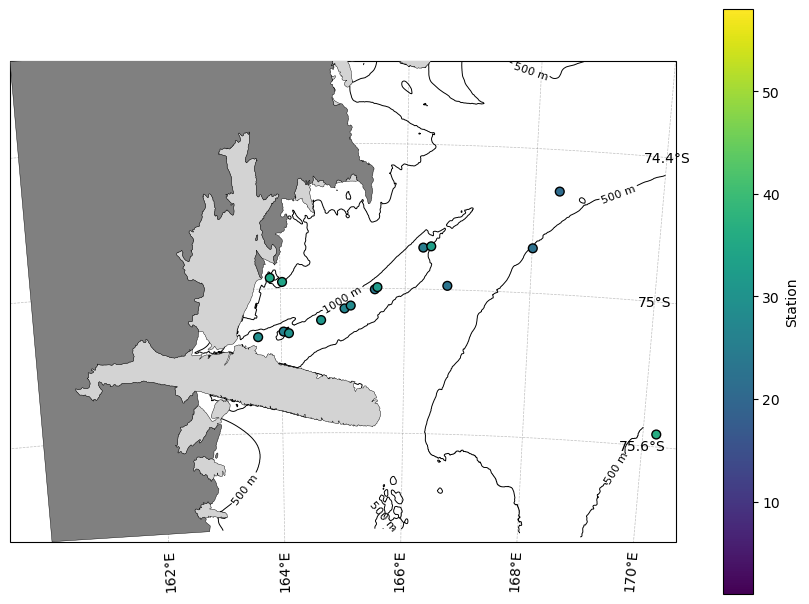

In [21]:
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=160,
    lon_max=170,
    lat_min=-76,
    lat_max=-74,
    contour_levels=[500, 1000, 1500, 2000, 3000],
    gridline_lats=[-75.6, -75.0, -74.4],
    gridline_lons=[162, 164, 166, 168, 170],
)

stations = list(casts.keys())
lons = [float(ds.lon) for ds in casts.values()]
lats = [float(ds.lat) for ds in casts.values()]

sc = ax.scatter(
    lons,
    lats,
    c=stations,
    cmap='viridis',
    s=40,
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

# ax.text(
#     lon,
#     lat,
#     str(station),
#     transform=ccrs.PlateCarree(),
#     fontsize=8,
#     ha='left',
#     va='bottom',
#     zorder=11
# )

plt.colorbar(sc, ax=ax, label='Station')

In [22]:
import xarray as xr
import numpy as np

def casts_to_station_dataset(casts):
    ds_list = []

    for station, ds in casts.items():

        # rename press dimension to sample, but keep press as a coordinate
        prof = ds.rename({"press": "sample"})

        prof = prof.assign_coords(
            station=station,
            press=("sample", ds["press"].values)
        )

        # add station dimension
        prof = prof.expand_dims("station")

        ds_list.append(prof)

    combined = xr.concat(ds_list, dim="station")

    return combined

In [23]:
ctd = casts_to_station_dataset(casts)

C:\Users\mblan\AppData\Local\Temp\ipykernel_12240\3141579098.py:22: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'sample' ('sample',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(ds_list, dim="station")
C:\Users\mblan\AppData\Local\Temp\ipykernel_12240\3141579098.py:22: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  combined = xr.concat(ds_list, dim="station")


In [61]:
ctd

<xarray.Dataset> Size: 35MB
Dimensions:                   (station: 58, sample: 3918)
Coordinates:
  * station                   (station) int64 464B 1 2 3 4 5 ... 54 55 56 57 58
  * sample                    (sample) int64 31kB 1 2 3 4 ... 3916 3917 3918
    lat                       (station) float64 464B -60.0 -65.5 ... -66.15
    lon                       (station) float64 464B 170.0 172.0 ... -175.3
    time                      (station) datetime64[ns] 464B 2017-04-16T00:20:...
    press                     (station, sample) float64 2MB nan nan ... nan nan
Data variables: (12/18)
    depth                     (station, sample) float64 2MB nan nan ... nan nan
    temp                      (station, sample) float64 2MB nan nan ... nan nan
    cond                      (station, sample) float64 2MB nan nan ... nan nan
    O2                        (station, sample) float64 2MB nan nan ... nan nan
    theta                     (station, sample) float64 2MB nan nan ... nan nan
    sal                       (station, sample) float64 2MB nan nan ... nan nan
    ...                        ...
    FLBB2                     (station, sample) float64 2MB nan nan ... nan nan
    Absolute_Salinity         (station, sample) float64 2MB nan nan ... nan nan
    Potential_Temperature     (station, sample) float64 2MB nan nan ... nan nan
    Conservative_Temperature  (station, sample) float64 2MB nan nan ... nan nan
    Potential_Density         (station, sample) float64 2MB nan nan ... nan nan
    N2                        (station, sample) float64 2MB nan nan ... nan nan
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

In [66]:
import matplotlib.pyplot as plt

def plot_ctd_profiles(ctd_tnb):
    fig, axes = plt.subplots(
        nrows=1, ncols=3,
        figsize=(10, 6),
        sharey=True,
        constrained_layout=True
    )

    variables = ["Potential_Temperature", "Absolute_Salinity", "sigma_theta"]
    labels = [
        "Potential Temperature (°C)",
        "Absolute Salinity (psu)",
        r"$\sigma_\theta$ (kg m$^{-3}$)"
    ]

    for ax, var, label in zip(axes, variables, labels):

        for station in ctd_tnb.station.values:
            ds = ctd_tnb.sel(station=station)

            ax.plot(
                ds[var],
                ds["press"],
                lw=1,
                alpha=0.8,
                label=str(station),
                color='k'
            )

        ax.set_xlabel(label)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Pressure (db)")
    axes[0].invert_yaxis()

    # One shared legend outside plot
    # handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(
    #     handles,
    #     labels,
    #     title="Station",
    #     loc="center left",
    #     bbox_to_anchor=(1.02, 0.5),
    #     fontsize=8
    # )

    return fig, axes

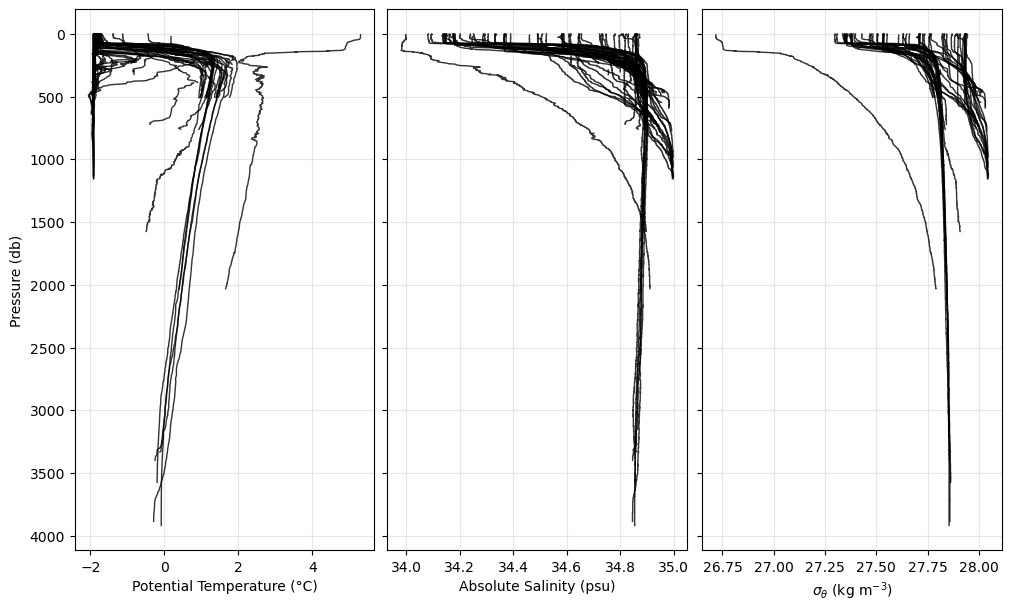

In [67]:
fig, axes = plot_ctd_profiles(ctd)

In [68]:
ctd

<xarray.Dataset> Size: 35MB
Dimensions:                   (station: 58, sample: 3918)
Coordinates:
  * station                   (station) int64 464B 1 2 3 4 5 ... 54 55 56 57 58
  * sample                    (sample) int64 31kB 1 2 3 4 ... 3916 3917 3918
    lat                       (station) float64 464B -60.0 -65.5 ... -66.15
    lon                       (station) float64 464B 170.0 172.0 ... -175.3
    time                      (station) datetime64[ns] 464B 2017-04-16T00:20:...
    press                     (station, sample) float64 2MB nan nan ... nan nan
Data variables: (12/18)
    depth                     (station, sample) float64 2MB nan nan ... nan nan
    temp                      (station, sample) float64 2MB nan nan ... nan nan
    cond                      (station, sample) float64 2MB nan nan ... nan nan
    O2                        (station, sample) float64 2MB nan nan ... nan nan
    theta                     (station, sample) float64 2MB nan nan ... nan nan
    sal                       (station, sample) float64 2MB nan nan ... nan nan
    ...                        ...
    FLBB2                     (station, sample) float64 2MB nan nan ... nan nan
    Absolute_Salinity         (station, sample) float64 2MB nan nan ... nan nan
    Potential_Temperature     (station, sample) float64 2MB nan nan ... nan nan
    Conservative_Temperature  (station, sample) float64 2MB nan nan ... nan nan
    Potential_Density         (station, sample) float64 2MB nan nan ... nan nan
    N2                        (station, sample) float64 2MB nan nan ... nan nan
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

In [71]:
ctd.lon[0]

<xarray.DataArray 'lon' ()> Size: 8B
array(170.001)
Coordinates:
    station  int64 8B 1
    lat      float64 8B -60.0
    lon      float64 8B 170.0
    time     datetime64[ns] 8B 2017-04-16T00:20:09.600000

In [76]:
for s in range(len(ctd.station)):
    print(ctd.station[s])

<xarray.DataArray 'station' ()> Size: 8B
array(1)
Coordinates:
    station  int64 8B 1
    lat      float64 8B -60.0
    lon      float64 8B 170.0
    time     datetime64[ns] 8B 2017-04-16T00:20:09.600000
<xarray.DataArray 'station' ()> Size: 8B
array(2)
Coordinates:
    station  int64 8B 2
    lat      float64 8B -65.5
    lon      float64 8B 172.0
    time     datetime64[ns] 8B 2017-04-17T18:07:12.000000256
<xarray.DataArray 'station' ()> Size: 8B
array(3)
Coordinates:
    station  int64 8B 3
    lat      float64 8B -67.5
    lon      float64 8B 172.0
    time     datetime64[ns] 8B 2017-04-18T12:28:48
<xarray.DataArray 'station' ()> Size: 8B
array(4)
Coordinates:
    station  int64 8B 4
    lat      float64 8B -68.57
    lon      float64 8B 172.1
    time     datetime64[ns] 8B 2017-04-19T04:00:28.799999744
<xarray.DataArray 'station' ()> Size: 8B
array(5)
Coordinates:
    station  int64 8B 5
    lat      float64 8B -68.92
    lon      float64 8B 172.0
    time     datetime64[ns] 8B 2

Text(0, 0.5, 'Potential Temperature')

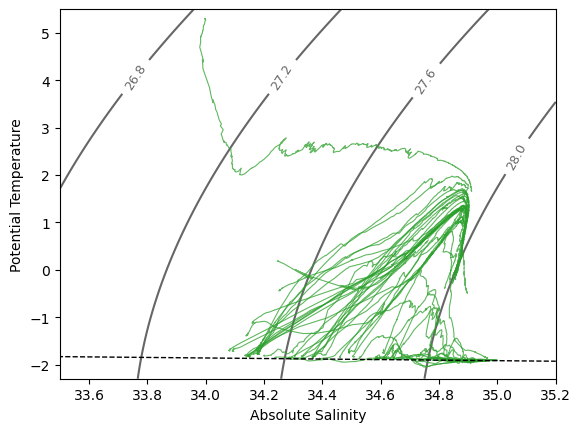

In [85]:
# make a T/S Diagram 
# =====================================================
# Panel 3: T/S diagram
# =====================================================
fig, ax = plt.subplots()

# T/S diagram limits
mint = -2.3
maxt = 6
mins = 33.0
maxs = 35.2

tempL = np.linspace(mint, maxt, 100)
salL = np.linspace(mins, maxs, 100)
Tg, Sg = np.meshgrid(tempL, salL)

lon = float(ctd.lon[0])
lat = float(ctd.lat[0])
p_ref = float(np.nanmax(ctd['press']))

# Density contours
SA_grid = gsw.SA_from_SP(Sg, p_ref, lon, lat)

# If temp_var is theta/potential temperature, this is reasonable:
CT_grid = gsw.CT_from_pt(SA_grid, Tg)

sigma_theta = gsw.sigma0(SA_grid, CT_grid)

cs = ax.contour(
    Sg,
    Tg,
    sigma_theta,
    colors="k",
    alpha=0.6,
    levels=6,
    zorder=1
)

ax.clabel(cs, fontsize=9, inline=True)

# Freezing line
SA_freeze = gsw.SA_from_SP(salL, 0, lon, lat)
t_freezing = gsw.t_freezing(
    SA_freeze,
    p=0,
    saturation_fraction=0
)

# All casts in background
# if ts_background:
#     for bg_st in ctd.station.values:
#         bg = ctd.sel(station=bg_st)

for s in range(len(ctd.station)):
    ax.plot(
        ctd.isel(station=s)['Absolute_Salinity'],
        ctd.isel(station=s)['Potential_Temperature'],
        color="tab:green",
        lw=0.8,
        alpha=0.75,
        zorder=2
    )

ax.plot(
    salL,
    t_freezing,
    "k--",
    lw=1,
    label="Freezing line"
)

ax.set_xlim(33.5,35.2)
ax.set_ylim(-2.3,5.5)
ax.set_xlabel('Absolute Salinity')
ax.set_ylabel('Potential Temperature')

In [26]:
import matplotlib.pyplot as plt

def plot_ctd_profile(ctd_tnb, station):
    ds = ctd_tnb.sel(station=station)

    fig, axes = plt.subplots(
        nrows=1, ncols=3,
        figsize=(10, 6),
        sharey=True,
        constrained_layout=True
    )

    variables = ["temp", "sal", "sigma_theta"]
    labels = [
        "Temperature (°C)",
        "Salinity (psu)",
        r"$\sigma_\theta$ (kg m$^{-3}$)"
    ]

    for ax, var, label in zip(axes, variables, labels):

        ax.plot(
            ds[var],
            ds["press"],
            color='k',
            lw=2
        )

        ax.set_xlabel(label)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Pressure (db)")
    axes[0].invert_yaxis()

    fig.suptitle(f"CTD Station {station}", fontsize=12)

    return fig, axes

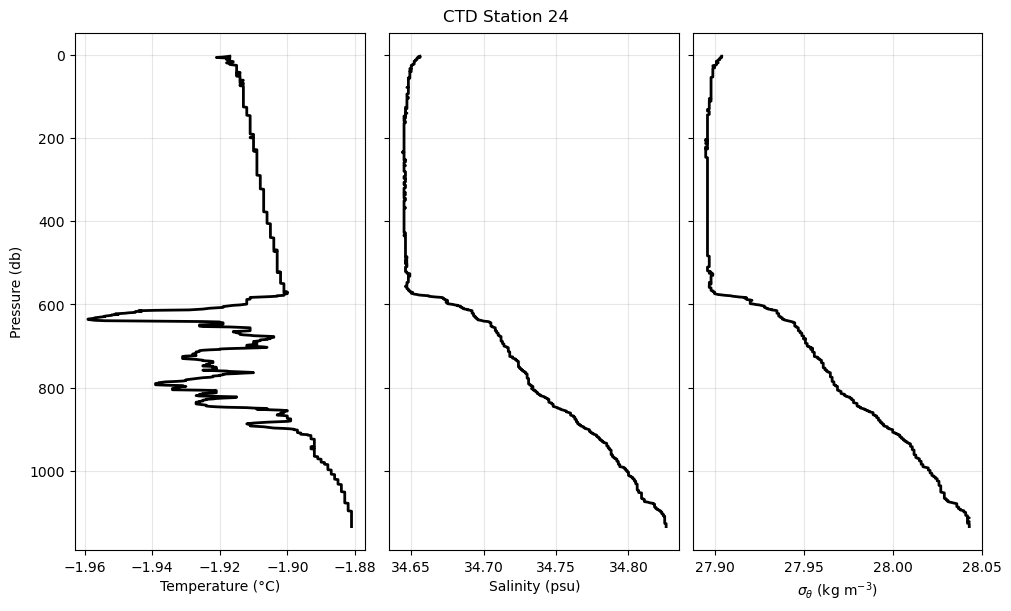

In [31]:
fig, axes = plot_ctd_profile(ctd_tnb, station=24)

In [40]:
# need to calculate TEOS-10 Variables 

In [27]:
import gsw

In [28]:
ctd['Absolute_Salinity'] = gsw.SA_from_SP(ctd.sal,ctd.press,ctd.lon,ctd.lat)
# should a reference pressure of zero be used? 
ctd['Potential_Temperature'] = gsw.pt_from_t(ctd.Absolute_Salinity,ctd.temp,ctd.press,0)
ctd['Conservative_Temperature'] = gsw.CT_from_pt(ctd.Absolute_Salinity,ctd.Potential_Temperature)
ctd['Potential_Density'] = gsw.sigma0(ctd.Absolute_Salinity,ctd.Conservative_Temperature)

In [29]:
import numpy as np
import xarray as xr
import mixsea as mx

def add_N2_to_ctd(ctd, bin_width=20):
    ctd = ctd.copy()

    # empty output array matching temp/sal shape
    N2_out = xr.full_like(ctd["temp"], np.nan).rename("N2")

    for st in ctd.station.values:
        cast = ctd.sel(station=st)

        S = cast["sal"].values
        T = cast["temp"].values
        p = cast["press"].values
        lat = float(cast["lat"])
        lon = float(cast["lon"])

        good = np.isfinite(S) & np.isfinite(T) & np.isfinite(p)

        if good.sum() < 5:
            print(f"Skipping station {st}: not enough valid data")
            continue

        S_good = S[good]
        T_good = T[good]
        p_good = p[good]

        N2 = mx.nsq.adiabatic_leveling(
            P=p_good,
            S=S_good,
            T=T_good,
            lon=lon,
            lat=lat,
            bin_width=bin_width,
            cap=None
        )

        # put N2 back into original sample positions
        N2_full = np.full_like(p, np.nan, dtype=float)
        N2_full[good] = N2

        N2_out.loc[dict(station=st)] = N2_full

    N2_out.attrs = {
        "long_name": "Brunt-Vaisala frequency squared",
        "units": "s^-2",
        "method": "mixsea adiabatic leveling",
        "bin_width": bin_width,
    }

    ctd["N2"] = N2_out

    return ctd

In [30]:
ctd = add_N2_to_ctd(ctd, bin_width=20)

c:\Users\mblan\miniforge3\envs\TNB\Lib\site-packages\mixsea\nsq.py:254: RankWarning: Polyfit may be poorly conditioned
  p[:, i] = np.polyfit(Pb[:imax, i], sv[:imax, i], order)


In [86]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gsw

def plot_all_ctd_TS_N2_profiles(
    ctd,
    out_dir="ctd_TS_plots_PIPERS",
    temp_var="Potential_Temperature",      # use "temp" if you want in-situ temperature
    sal_var="Absolute_Salinity",
    oxy_var="O2",
    N2_var="N2",
    press_var="press",
    ts_background=True,
    save=True,
):
    os.makedirs(out_dir, exist_ok=True)

    # T/S diagram limits
    mint = -2.3
    maxt = 6
    mins = 33.0
    maxs = 35.2

    tempL = np.linspace(mint, maxt, 100)
    salL = np.linspace(mins, maxs, 100)
    Tg, Sg = np.meshgrid(tempL, salL)

    for st in ctd.station.values:

        cast = ctd.sel(station=st)

        fig = plt.figure(figsize=(11, 5.5), constrained_layout=True)

        gs = fig.add_gridspec(
            nrows=1,
            ncols=3,
            width_ratios=[1.0, 1.0, 1.35]
        )

        ax_prof = fig.add_subplot(gs[0, 0])
        ax_N2 = fig.add_subplot(gs[0, 1], sharey=ax_prof)
        ax_TS = fig.add_subplot(gs[0, 2])

        # =====================================================
        # Panel 1: Temperature + Salinity profiles
        # =====================================================
        ax_sal = ax_prof.twiny()

        ax_prof.plot(
            cast[temp_var],
            cast[press_var],
            color="tab:blue",
            label="Potential Temperature"
        )

        ax_prof.set_xlabel("Potential Temperature [°C]", color="tab:blue")
        ax_prof.set_ylabel("Pressure [dbar]")
        ax_prof.tick_params(axis="x", colors="tab:blue")
        ax_prof.invert_yaxis()

        ax_sal.plot(
            cast[sal_var],
            cast[press_var],
            color="tab:orange",
            label="Practical Salinity"
        )

        ax_sal.set_xlabel("Practical Salinity [psu]", color="tab:orange")
        ax_sal.tick_params(axis="x", colors="tab:orange")

        ax_prof.grid(alpha=0.3)
        ax_prof.set_title("T/S Profiles")

        # =====================================================
        # Panel 2: N2 profile
        # =====================================================
        if N2_var in ctd:
            ax_N2.semilogx(
                cast[N2_var],
                cast[press_var],
                color="k"
            )

            ax_N2.set_xlabel(r"$N^2$ [s$^{-2}$]")
            ax_N2.grid(alpha=0.3)
            ax_N2.set_title(r"$N^2$")
        else:
            ax_N2.text(
                0.5, 0.5,
                "N2 not found",
                ha="center",
                va="center",
                transform=ax_N2.transAxes
            )
            ax_N2.set_title(r"$N^2$")

        plt.setp(ax_N2.get_yticklabels(), visible=False)

        # =====================================================
        # Panel 3: T/S diagram
        # =====================================================
        lon = float(cast.lon)
        lat = float(cast.lat)
        p_ref = float(np.nanmax(cast[press_var]))

        # Density contours
        SA_grid = gsw.SA_from_SP(Sg, p_ref, lon, lat)

        # If temp_var is theta/potential temperature, this is reasonable:
        CT_grid = gsw.CT_from_pt(SA_grid, Tg)

        sigma_theta = gsw.sigma0(SA_grid, CT_grid)

        cs = ax_TS.contour(
            Sg,
            Tg,
            sigma_theta,
            colors="k",
            alpha=0.6,
            levels=6,
            zorder=1
        )

        ax_TS.clabel(cs, fontsize=9, inline=True)

        # Freezing line
        SA_freeze = gsw.SA_from_SP(salL, 0, lon, lat)
        t_freezing = gsw.t_freezing(
            SA_freeze,
            p=0,
            saturation_fraction=0
        )

        # All casts in background
        if ts_background:
            for bg_st in ctd.station.values:
                bg = ctd.sel(station=bg_st)

                ax_TS.plot(
                    bg[sal_var],
                    bg[temp_var],
                    color="0.75",
                    lw=0.8,
                    alpha=0.5,
                    zorder=2
                )

        ax_TS.plot(
            salL,
            t_freezing,
            "k--",
            lw=1,
            label="Freezing line"
        )

        # Current cast colored by oxygen
        sc = ax_TS.scatter(
            cast[sal_var],
            cast[temp_var],
            c=cast[oxy_var],
            s=12,
            cmap="viridis",
            zorder=4
        )

        cb = fig.colorbar(
            sc,
            ax=ax_TS,
            label="Dissolved Oxygen [mL/L]",
            shrink=0.85
        )

        ax_TS.set_xlabel("Practical Salinity [psu]")
        ax_TS.set_ylabel("Potential Temperature [°C]")
        ax_TS.set_xlim(33.5,35.2)
        ax_TS.set_ylim(-2.3,5.5)
        ax_TS.set_title("T/S Diagram")
        ax_TS.grid(alpha=0.3)
        ax_TS.legend(fontsize=8, loc="best")
        ax_TS.set_box_aspect(1)

        # =====================================================
        # Figure title
        # =====================================================
        title = f"Station {int(st)}"

        if "time" in cast.coords:
            try:
                date = np.datetime_as_string(cast.time.values, unit="D")
                title += f", {date}"
            except Exception:
                pass

        fig.suptitle(title, fontsize=14)

        # =====================================================
        # Save
        # =====================================================
        if save:
            filename = f"station_{int(st):02d}.png"
            filepath = os.path.join(out_dir, filename)
            fig.savefig(filepath, dpi=300)
            plt.close(fig)

    return

In [87]:
plot_all_ctd_TS_N2_profiles(
    ctd=ctd,
    out_dir="ctd_TS_plots_PIPERS",
    temp_var="Potential_Temperature",
    sal_var="Absolute_Salinity",
    oxy_var="O2",
    N2_var="N2",
    press_var="press",
    save=True
)

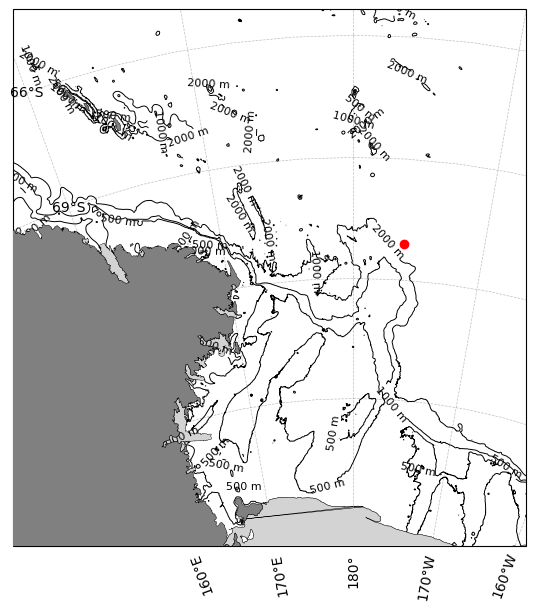

In [105]:
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=160,
    lon_max=190,
    lat_min=-78,
    lat_max=-65,
    central_longitude=180,
    contour_levels=[500,1000,2000],
    gridline_lons=[160, 170, 180, -170, -160],
    gridline_lats=[-75, -72, -69, -66, -63, -60],
    label_contours=True,
)

# stations = list(casts.keys())
# lons = [float(ds.lon) for ds in casts.values()]
# lats = [float(ds.lat) for ds in casts.values()]
station = 48
lon = casts[station].lon
lat = casts[station].lat

ax.scatter(lon,lat,color='r',transform=ccrs.PlateCarree(),zorder=10)

# sc = ax.scatter(
#     lons,
#     lats,
#     c=stations,
#     cmap='viridis',
#     s=40,
#     edgecolor='k',
#     transform=ccrs.PlateCarree(),
#     zorder=10
# )

# plt.colorbar(sc, ax=ax, label='Station')

### subset TNB casts

In [32]:
# select lat and lon to get TNB subset 
lon_min, lon_max = 162, 170
lat_min, lat_max = -75.75, -74.25
ctd_tnb = ctd.where(
    (ctd.lon >= lon_min) &
    (ctd.lon <= lon_max) &
    (ctd.lat >= lat_min) &
    (ctd.lat <= lat_max),
    drop=True
)

In [33]:
ctd_tnb

<xarray.Dataset> Size: 9MB
Dimensions:                   (station: 15, sample: 3918)
Coordinates:
  * station                   (station) int64 120B 21 22 23 24 ... 32 33 34 35
  * sample                    (sample) int64 31kB 1 2 3 4 ... 3916 3917 3918
    lat                       (station) float64 120B -74.57 -74.81 ... -74.95
    lon                       (station) float64 120B 168.4 168.0 ... 164.0 163.8
    time                      (station) datetime64[ns] 120B 2017-04-29T15:56:...
    press                     (station, sample) float64 470kB nan 2.0 ... nan
Data variables: (12/18)
    depth                     (station, sample) float64 470kB nan 1.98 ... nan
    temp                      (station, sample) float64 470kB nan -1.889 ... nan
    cond                      (station, sample) float64 470kB nan 2.706 ... nan
    O2                        (station, sample) float64 470kB nan 7.684 ... nan
    theta                     (station, sample) float64 470kB nan -1.889 ... nan
    sal                       (station, sample) float64 470kB nan 34.49 ... nan
    ...                        ...
    FLBB2                     (station, sample) float64 470kB nan nan ... nan
    Absolute_Salinity         (station, sample) float64 470kB nan 34.65 ... nan
    Potential_Temperature     (station, sample) float64 470kB nan -1.889 ... nan
    Conservative_Temperature  (station, sample) float64 470kB nan -1.886 ... nan
    Potential_Density         (station, sample) float64 470kB nan 27.77 ... nan
    N2                        (station, sample) float64 470kB nan ... nan
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

In [56]:
%matplotlib widget

In [145]:
sec

<xarray.DataArray 'sigma_theta' (x: 16, press: 316)> Size: 40kB
array([[   nan, 27.829, 27.827, ...,    nan,    nan,    nan],
       [   nan, 27.843, 27.842, ...,    nan,    nan,    nan],
       [   nan, 27.944, 27.943, ...,    nan,    nan,    nan],
       ...,
       [   nan, 27.708, 27.708, ...,    nan,    nan,    nan],
       [   nan, 27.71 , 27.71 , ...,    nan,    nan,    nan],
       [   nan, 27.632, 27.632, ..., 27.907, 27.907, 27.908]],
      shape=(16, 316))
Coordinates:
  * x             (x) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * press         (press) float64 3kB 0.0 5.0 10.0 ... 1.57e+03 1.575e+03
    station       (x) int64 128B 29 26 30 31 27 28 24 32 25 33 21 20 19 18 17 16
    distance      (x) float64 128B 0.0 12.05 14.59 30.61 ... 435.0 491.7 554.6
    bottom_press  (x) float64 128B 1.133e+03 985.0 1.041e+03 ... 492.0 1.575e+03
    lat           (x) float64 128B -75.2 -75.18 -75.18 ... -72.99 -72.48 -71.93
    lon           (x) float64 128B 163.6 164.0 164.1 164.7 ... 171.6 171.9 172.3

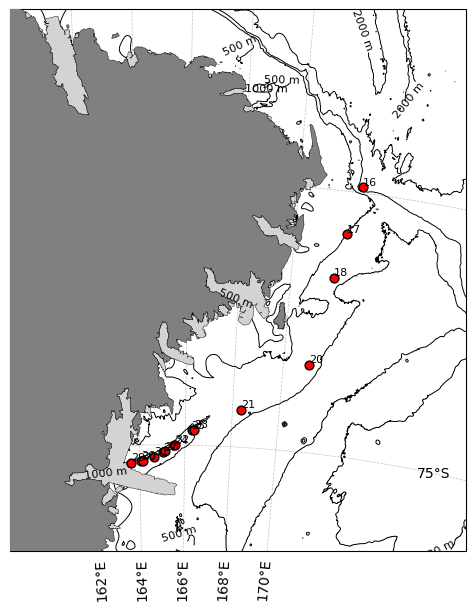

In [154]:
# plot study site 
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=160,
    lon_max=175,
    lat_min=-76,
    lat_max=-70,
    contour_levels=[500, 1000, 2000],
    gridline_lats=[-75.0, -72],
    gridline_lons=[162, 164, 166, 168, 170],
)

ax.scatter(
    sec.lon,
    sec.lat,
    s=40,
    color='red',
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Add station numbers
for lon, lat, st in zip(
    sec.lon.values,
    sec.lat.values,
    sec.station.values
):
    ax.text(
        lon,
        lat,
        str(int(st)),
        transform=ccrs.PlateCarree(),
        fontsize=8,
        ha='left',
        va='bottom',
        zorder=11
    )

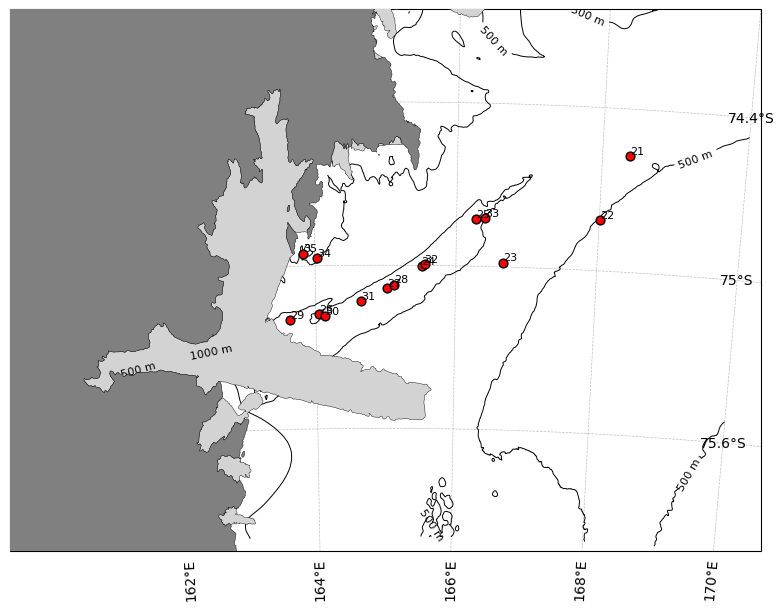

In [34]:
# plot study site 
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=160,
    lon_max=170,
    lat_min=-76,
    lat_max=-74,
    contour_levels=[500, 1000, 1500, 2000, 3000],
    gridline_lats=[-75.6, -75.0, -74.4],
    gridline_lons=[162, 164, 166, 168, 170],
)

ax.scatter(
    ctd_tnb.lon,
    ctd_tnb.lat,
    s=40,
    color='red',
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Add station numbers
for lon, lat, st in zip(
    ctd_tnb.lon.values,
    ctd_tnb.lat.values,
    ctd_tnb.station.values
):
    ax.text(
        lon,
        lat,
        str(int(st)),
        transform=ccrs.PlateCarree(),
        fontsize=8,
        ha='left',
        va='bottom',
        zorder=11
    )


In [107]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def make_simple_ctd_section(
    ctd,
    stations,
    var="sigma_theta",
    p_grid=None,
):
    if p_grid is None:
        pmax = float(ctd.sel(station=stations).press.max())
        p_grid = np.arange(0, pmax + 5, 5)

    section = []

    for i, st in enumerate(stations):
        cast = ctd.sel(station=st)

        p = cast.press.values
        y = cast[var].values

        good = np.isfinite(p) & np.isfinite(y)

        p = p[good]
        y = y[good]

        order = np.argsort(p)
        p = p[order]
        y = y[order]

        y_i = np.interp(p_grid, p, y, left=np.nan, right=np.nan)

        da = xr.DataArray(
            y_i,
            dims=["press"],
            coords={
                "press": p_grid,
                "x": i,
                "station": st,
                "bottom_press": np.nanmax(p),
            },
            name=var
        )

        section.append(da)

    section = xr.concat(section, dim="x")
    section = section.assign_coords(
        station=("x", stations),
        bottom_press=("x", [float(ctd.sel(station=st).press.max()) for st in stations])
    )

    return section

In [119]:
import numpy as np
import xarray as xr
import gsw

def make_simple_ctd_section(
    ctd,
    stations,
    var="sigma_theta",
    p_grid=None,
):

    # -----------------------------------
    # pressure grid
    # -----------------------------------
    if p_grid is None:
        pmax = float(ctd.sel(station=stations).press.max())
        p_grid = np.arange(0, pmax + 5, 5)

    # -----------------------------------
    # cumulative section distance
    # -----------------------------------
    lons = []
    lats = []

    for st in stations:
        cast = ctd.sel(station=st)

        lons.append(float(cast.lon))
        lats.append(float(cast.lat))

    lons = np.array(lons)
    lats = np.array(lats)

    # pairwise distances [m]
    dx = gsw.distance(lons, lats)

    # cumulative distance [km]
    dist = np.concatenate([[0], np.cumsum(dx) / 1000])

    # -----------------------------------
    # interpolate casts
    # -----------------------------------
    section = []

    for i, st in enumerate(stations):

        cast = ctd.sel(station=st)

        p = cast.press.values
        y = cast[var].values

        # remove NaNs
        good = np.isfinite(p) & np.isfinite(y)

        p = p[good]
        y = y[good]

        # sort
        order = np.argsort(p)

        p = p[order]
        y = y[order]

        # -----------------------------------
        # remove duplicate pressures
        # VERY important for interp
        # -----------------------------------
        p_unique, unique_idx = np.unique(p, return_index=True)

        y_unique = y[unique_idx]

        # interpolate
        y_i = np.interp(
            p_grid,
            p_unique,
            y_unique,
            left=np.nan,
            right=np.nan,
        )

        da = xr.DataArray(
            y_i,
            dims=["press"],
            coords={
                "press": p_grid,
                "x": i,
                "station": st,
                "distance": dist[i],
                "bottom_press": np.nanmax(p_unique),
                "lat": lats[i],
                "lon": lons[i],
            },
            name=var,
        )

        section.append(da)

    # -----------------------------------
    # concatenate
    # -----------------------------------
    section = xr.concat(section, dim="x")

    section = section.assign_coords(
        station=("x", stations),
        distance=("x", dist),
        bottom_press=(
            "x",
            [float(ctd.sel(station=st).press.max()) for st in stations],
        ),
        lat=("x", lats),
        lon=("x", lons),
    )

    return section

In [150]:
trough_stations = [29, 26, 30, 31, 27, 28, 24, 32, 25, 33, 21, 20, 18, 17, 16]

In [121]:
sec

<xarray.DataArray 'sigma_theta' (x: 16, press: 316)> Size: 40kB
array([[   nan, 27.829, 27.827, ...,    nan,    nan,    nan],
       [   nan, 27.843, 27.842, ...,    nan,    nan,    nan],
       [   nan, 27.944, 27.943, ...,    nan,    nan,    nan],
       ...,
       [   nan, 27.708, 27.708, ...,    nan,    nan,    nan],
       [   nan, 27.71 , 27.71 , ...,    nan,    nan,    nan],
       [   nan, 27.632, 27.632, ..., 27.907, 27.907, 27.908]],
      shape=(16, 316))
Coordinates:
  * x             (x) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * press         (press) float64 3kB 0.0 5.0 10.0 ... 1.57e+03 1.575e+03
    station       (x) int64 128B 29 26 30 31 27 28 24 32 25 33 21 20 19 18 17 16
    bottom_press  (x) float64 128B 1.133e+03 985.0 1.041e+03 ... 492.0 1.575e+03

In [151]:
sec = make_simple_ctd_section(
    ctd,
    stations=trough_stations,
    var="sigma_theta"
)

C:\Users\mblan\AppData\Local\Temp\ipykernel_12240\1724054635.py:101: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  section = xr.concat(section, dim="x")


In [152]:
sec.T

<xarray.DataArray 'sigma_theta' (press: 316, x: 15)> Size: 38kB
array([[   nan,    nan,    nan, ...,    nan,    nan,    nan],
       [27.829, 27.843, 27.944, ..., 27.708, 27.71 , 27.632],
       [27.827, 27.842, 27.943, ..., 27.708, 27.71 , 27.632],
       ...,
       [   nan,    nan,    nan, ...,    nan,    nan, 27.907],
       [   nan,    nan,    nan, ...,    nan,    nan, 27.907],
       [   nan,    nan,    nan, ...,    nan,    nan, 27.908]],
      shape=(316, 15))
Coordinates:
  * press         (press) float64 3kB 0.0 5.0 10.0 ... 1.57e+03 1.575e+03
  * x             (x) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
    station       (x) int64 120B 29 26 30 31 27 28 24 32 25 33 21 20 18 17 16
    distance      (x) float64 120B 0.0 12.05 14.59 30.61 ... 373.3 430.0 492.9
    bottom_press  (x) float64 120B 1.133e+03 985.0 1.041e+03 ... 492.0 1.575e+03
    lat           (x) float64 120B -75.2 -75.18 -75.18 ... -72.99 -72.48 -71.93
    lon           (x) float64 120B 163.6 164.0 164.1 164.7 ... 171.6 171.9 172.3

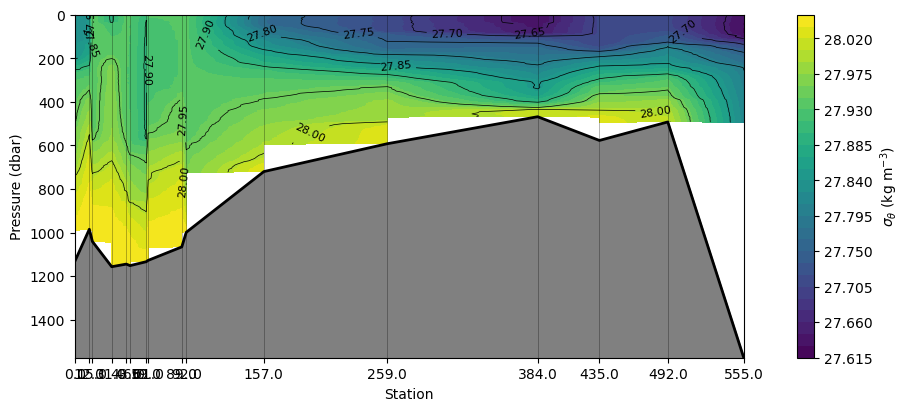

In [132]:
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

cf = ax.contourf(
    sec.distance,
    sec.press,
    sec.T,
    levels=30,
    cmap="viridis"
)

cs = ax.contour(
    sec.distance,
    sec.press,
    sec.T,
    colors="k",
    linewidths=0.5,
    levels=8
)

ax.clabel(cs, fontsize=8)

# plot cast locations as vertical lines
for x in sec.distance.values:
    ax.axvline(x, color="k", lw=0.5, alpha=0.4)

# plot bottom depth from each cast
ax.plot(
    sec.distance,
    sec.bottom_press,
    color="k",
    lw=2
)

# shade below bottom
ax.fill_between(
    sec.distance,
    sec.bottom_press,
    sec.press.max(),
    color="0.5"
)

ax.invert_yaxis()
ax.set_ylabel("Pressure (dbar)")
ax.set_xlabel("Station")

ax.set_xticks(sec.distance.values)
ax.set_xticklabels(np.round(sec.distance.values,0))

cbar = plt.colorbar(cf, ax=ax)
cbar.set_label(r"$\sigma_\theta$ (kg m$^{-3}$)")

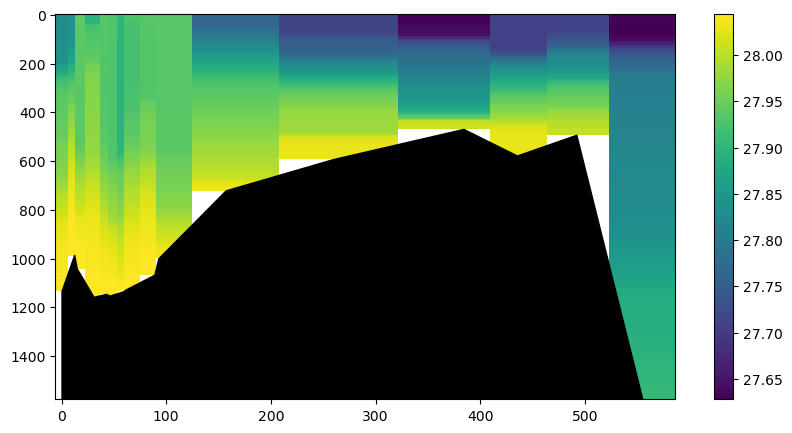

In [139]:
fig, ax = plt.subplots(figsize=(10,5))

pcm = ax.pcolormesh(
    sec.distance,
    sec.press,
    sec.T,   # <-- transpose fixes it
    shading='nearest',
    cmap='viridis'
)

ax.invert_yaxis()

ax.fill_between(
    sec.distance,
    sec.bottom_press,
    sec.press.max(),
    color='k'
)

plt.colorbar(pcm, ax=ax)

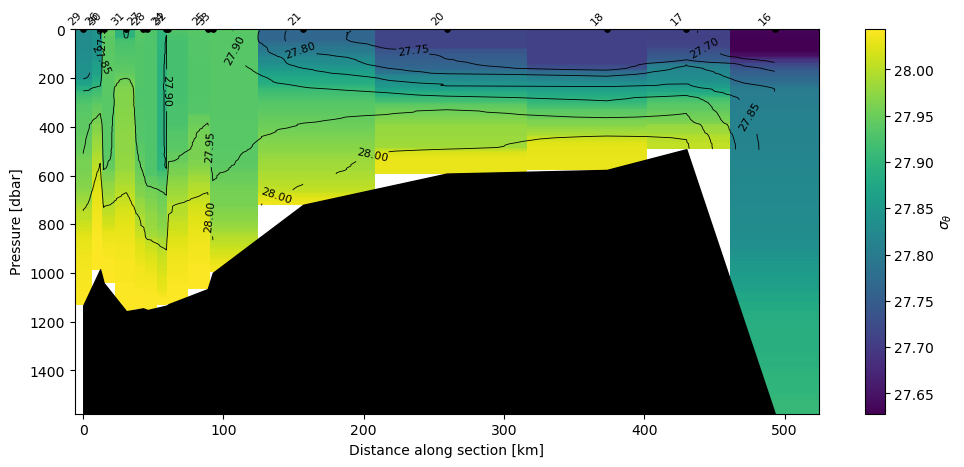

In [153]:
fig, ax = plt.subplots(figsize=(12,5))

# -----------------------------
# Filled section
# -----------------------------
pcm = ax.pcolormesh(
    sec.distance,
    sec.press,
    sec.T,
    shading='nearest',
    cmap='viridis'
)

# -----------------------------
# Density contours
# -----------------------------
cs = ax.contour(
    sec.distance,
    sec.press,
    sec.T,
    levels=np.arange(27.7, 28.1, 0.05),
    colors='k',
    linewidths=0.6
)

ax.clabel(
    cs,
    fontsize=8,
    fmt='%.2f'
)

# -----------------------------
# Bottom bathymetry fill
# -----------------------------
ax.fill_between(
    sec.distance,
    sec.bottom_press,
    sec.press.max(),
    color='k'
)

# -----------------------------
# Station locations
# -----------------------------
ax.scatter(
    sec.distance,
    np.zeros_like(sec.distance),
    color='k',
    s=15,
    zorder=10
)

# optional station labels
for i, st in enumerate(sec.station.values):

    ax.text(
        sec.distance[i],
        -20,
        str(st),
        rotation=45,
        ha='right',
        fontsize=8
    )

# -----------------------------
# Formatting
# -----------------------------
ax.invert_yaxis()

ax.set_xlabel('Distance along section [km]')
ax.set_ylabel('Pressure [dbar]')

plt.colorbar(
    pcm,
    ax=ax,
    label=r'$\sigma_\theta$'
)